In [51]:
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector

[Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm)

In [85]:
def dj_query(num_qubits):
    # Create a circuit implementing for a query gate for a random function
    # satisfying the promise for the Deutsch-Jozsa problem.
 
    qc = QuantumCircuit(num_qubits + 1)
 
    qc.barrier()
    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
        qc.barrier()
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc
 
    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )
 
    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc
 
    for state in on_states:
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
  
    return qc

In [71]:
def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa algorithm.
 
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.barrier()
    qc.compose(function, inplace=True)
    qc.barrier()
    qc.h(range(n))
    
    print("Bloch sphere:")
    display(plot_bloch_multivector(Statevector.from_instruction(qc)))
    
    qc.measure(range(n), range(n))
    return qc

In [72]:
def dj_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.
 
    qc = compile_circuit(function)
    
    print("Deutsch-Jozsa circuit:")
    display(qc.draw("mpl"))
 
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

Function circuit:


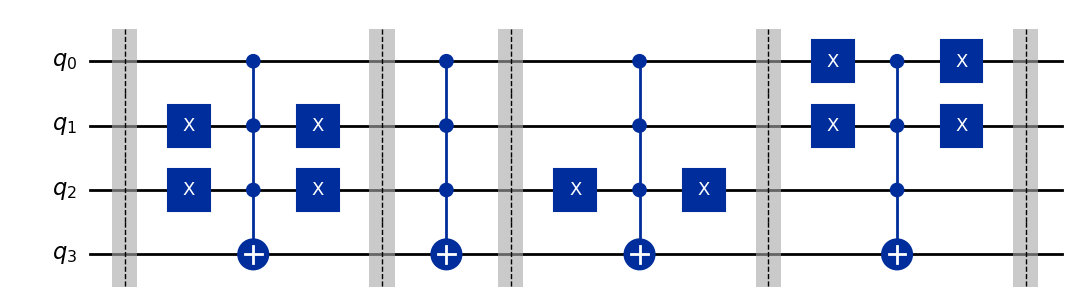

Bloch sphere:


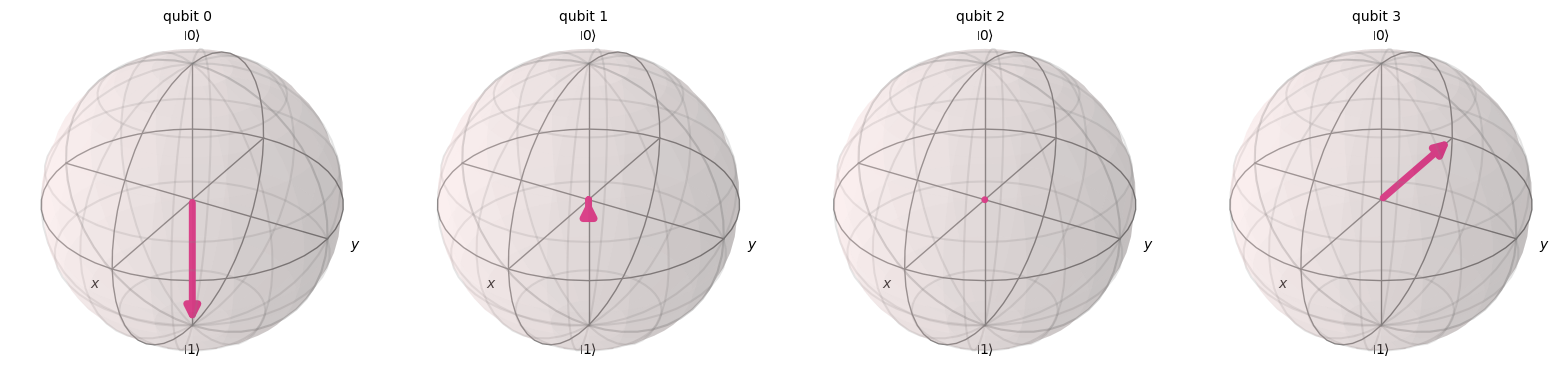

Deutsch-Jozsa circuit:


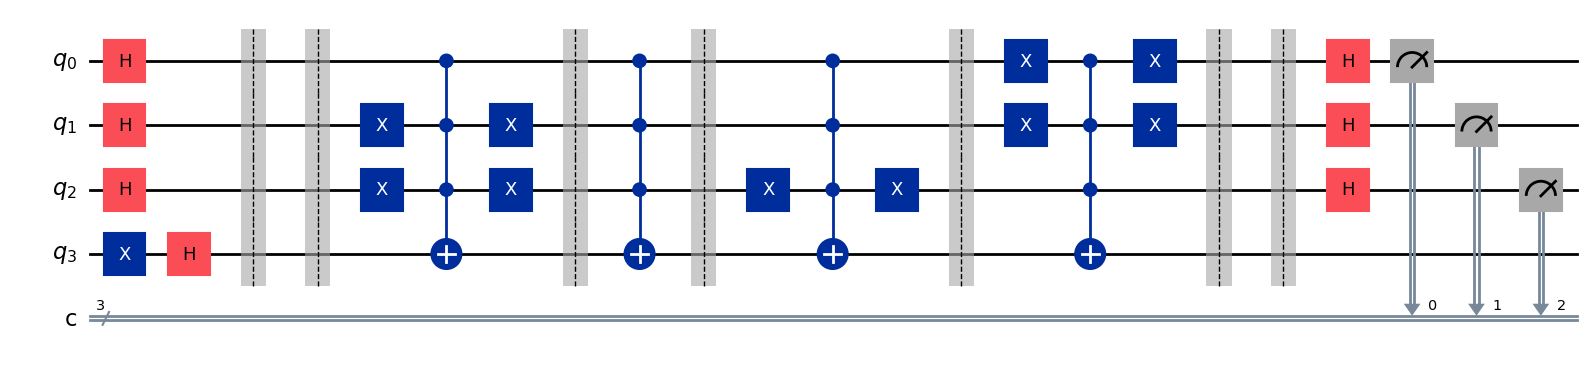

'The function is: balanced'

In [104]:
f = dj_query(3)
print("Function circuit:")
display(f.draw("mpl"))
display("The function is: " + dj_algorithm(f))